In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/NEW-hr_employee_attrition_raw.csv')

display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [45]:
# =========================
# Dataset Overview
# =========================

print(f"Dataset shape: {df.shape}")

print("\nColumn names:")
display(df.columns)

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nTarget distribution (Attrition):")
display(df["Attrition"].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


Dataset shape: (1470, 35)

Column names:


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


Data types:


,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64



Missing values:


,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0



Target distribution (Attrition):


,proportion
Attrition,
No,83.9%
Yes,16.1%


In [46]:
# =========================
# Data cleaning
# =========================

# Removing columns with no variance, as they do not provide useful information for the analysis

df.nunique()

constant_cols = df.columns[df.nunique() == 1]

df = df.drop(columns=constant_cols)

print("Removed columns:", list(constant_cols))

Removed columns: ['EmployeeCount', 'Over18', 'StandardHours']


In [47]:
# =========================
# Attrition Analysis (Numerical Features)
# =========================

attrition_means = df.groupby("Attrition").mean(numeric_only=True)

display(attrition_means)

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Attrition,,,,,,,,,,,,,,,,,,,,,
No,37.561233,812.504461,8.915653,2.927007,1027.656123,2.771290,65.952149,2.770479,2.145985,2.778589,...,3.153285,2.733982,0.845093,11.862936,2.832928,2.781022,7.369019,4.484185,2.234388,4.367397
Yes,33.607595,750.362869,10.632911,2.839662,1010.345992,2.464135,65.573840,2.518987,1.637131,2.468354,...,3.156118,2.599156,0.527426,8.244726,2.624473,2.658228,5.130802,2.902954,1.945148,2.852321


In [48]:
df['StockOptionLevel'].describe()

display(df["StockOptionLevel"].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

,proportion
StockOptionLevel,
0,42.9%
1,40.5%
2,10.7%
3,5.8%


# ADDING NEW FEATURES

In [49]:
# =========================
# Feature Engineering
# =========================

# 1. Promotion Delay Ratio
# Captures career stagnation relative to company tenure.
#
# ------------------------
# OBSERVED DISTRIBUTION:
# Low (0% - 25%)       → < 0.14
# Medium (25% - 75%)   → 0.14 - 0.43
# High (75% - 100%)    → > 0.43
# ------------------------
#
# INTERPRETATION:
# VALUE      |     MEANING
# Low        |     Recent promotions or active career progression
# High       |     Potential career stagnation and slower internal growth
# ------------------------

df["promotion_delay"] = (
    df["YearsSinceLastPromotion"] /
    (df["YearsAtCompany"] + 1)
)



# 2. Job Hopping Index
# Measures how frequently an employee has changed companies during their career.
#
# ------------------------
# OBSERVED DISTRIBUTION:
# Low (0% - 25%)       → < 0.09
# Medium (25% - 75%)   → 0.09 - 0.39
# High (75% - 100%)    → > 0.39
# ------------------------
#
# INTERPRETATION:
# VALUE      |     MEANING
# Low        |     Stable career history
# High       |     Frequent company changes
# ------------------------

df["job_hopping"] = (
    df["NumCompaniesWorked"] /
    (df["TotalWorkingYears"] + 1)
)



# 3. Engagement Score
# Aggregates satisfaction, involvement, and work-life balance into a single metric.
#
# ------------------------
# POSSIBLE RANGE:
# 3 → 12
# (derived from three features ranging from 1 to 4)
#
# OBSERVED DISTRIBUTION:
# Low (0% - 25%)       → < 7
# Medium (25% - 75%)   → 7 - 9
# High (75% - 100%)    → > 9
# ------------------------
#
# INTERPRETATION:
# VALUE      |     MEANING
# Low        |     Low employee engagement
# Medium     |     Moderate employee engagement
# High       |     Strong employee engagement
# ------------------------

df["engagement"] = (
    df["JobSatisfaction"] +
    df["JobInvolvement"] +
    df["WorkLifeBalance"]
)


In [50]:
# Statistics for each features added.

df[[
    "promotion_delay",
    "job_hopping",
    "engagement"
]].describe()

,promotion_delay,job_hopping,engagement
count,1470.000000,1470.000000,1470.000000
mean,0.236458,0.278598,8.219728
std,0.269358,0.294419,1.463890
min,0.000000,0.000000,4.000000
25%,0.000000,0.090909,7.000000
50%,0.142857,0.176471,8.000000
75%,0.428571,0.390700,9.000000
max,0.916667,2.250000,12.000000


# Engineered Features VS Attrition

In [51]:
# =========================
# Engineered Features vs Attrition
# =========================

engineered_features = [
    "promotion_delay",
    "job_hopping",
    "engagement",
]

attrition_analysis = df.groupby("Attrition")[engineered_features].mean()

display(attrition_analysis)

,promotion_delay,job_hopping,engagement
Attrition,,,
No,0.235228,0.252793,8.330089
Yes,0.242853,0.412852,7.645570


In [52]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

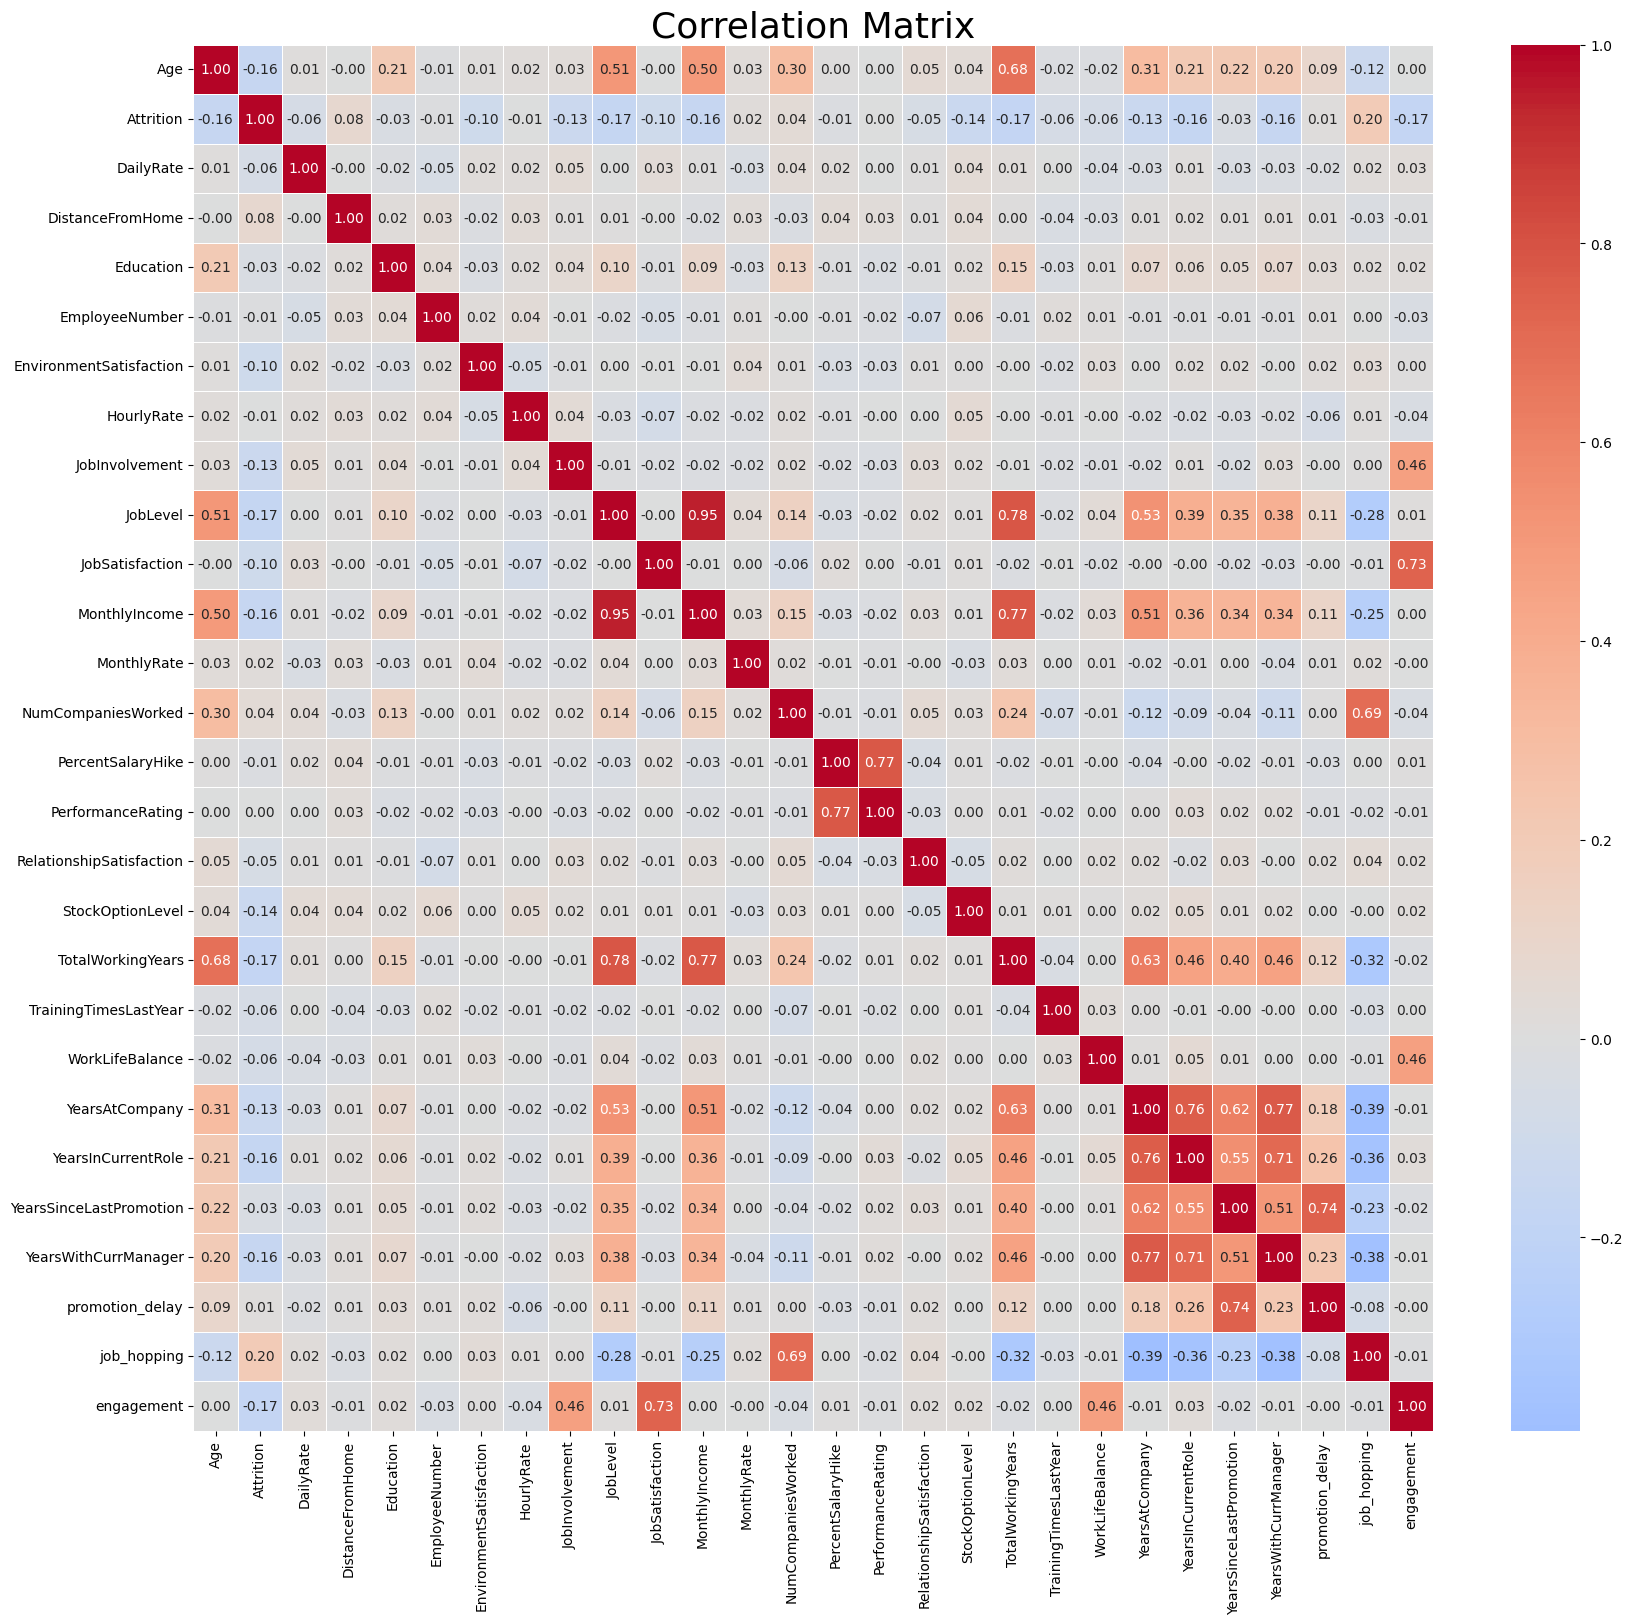

In [53]:
# =========================
# Correlation Matrix
# =========================

import seaborn as sns

# Compute correlations only for numerical features
correlation_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(20, 18))

sns.heatmap(
    correlation_matrix,
    annot = True,
    fmt = ".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=26)

plt.show()

In [54]:
# =========================
# Correlation with Attrition
# =========================

# Compute correlations with Attrition only
attrition_corr = (
    correlation_matrix["Attrition"]
    .sort_values(ascending=False)
)
minimo = min(attrition_corr)
massimo = max(attrition_corr)
display(attrition_corr)


,Attrition
Attrition,1.000000
job_hopping,0.199986
DistanceFromHome,0.077924
NumCompaniesWorked,0.043494
MonthlyRate,0.015170
promotion_delay,0.010412
PerformanceRating,0.002889
HourlyRate,-0.006846
EmployeeNumber,-0.010577
PercentSalaryHike,-0.013478


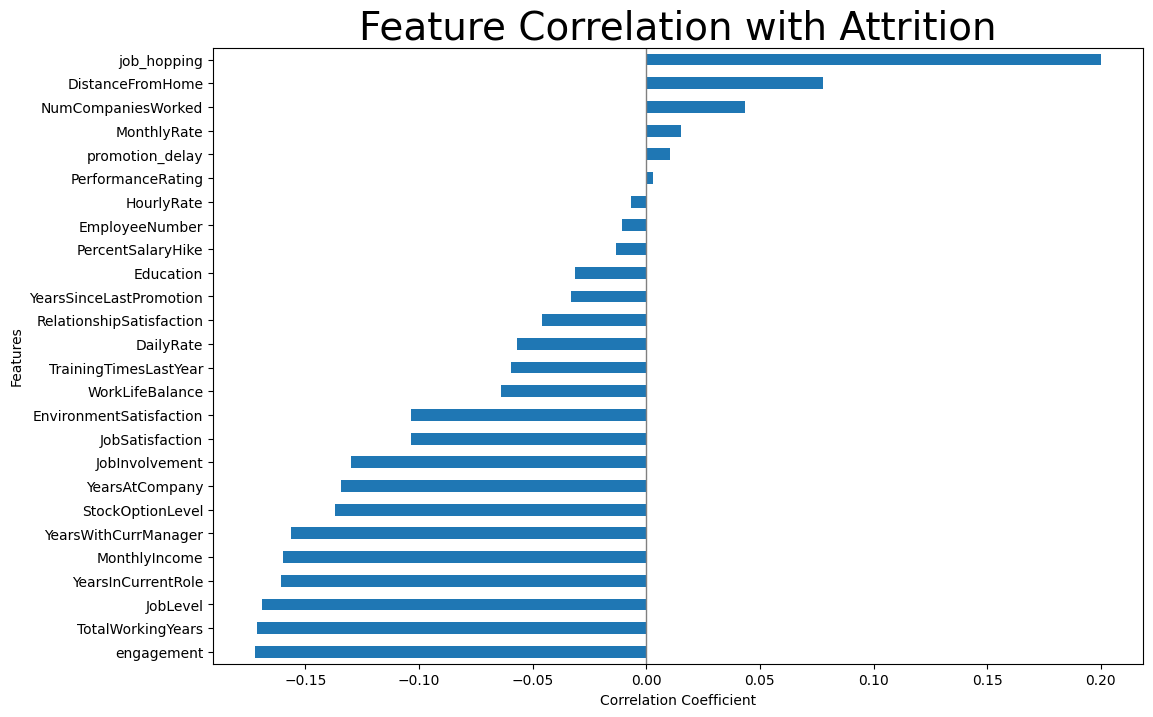

In [82]:
# =========================
# Correlation with Attrition (Barplot)
# =========================

# Remove Attrition itself from the plot
attrition_corr_plot = attrition_corr.drop(["Attrition","Age"])

# Create figure
plt.figure(figsize=(12, 8))

# Horizontal barplot
attrition_corr_plot.sort_values().plot(
    kind="barh"
)

# Title and labels
plt.title("Feature Correlation with Attrition", fontsize=28)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

# Add vertical reference line at 0
plt.axvline(0, color="grey", linewidth=1)

plt.show()

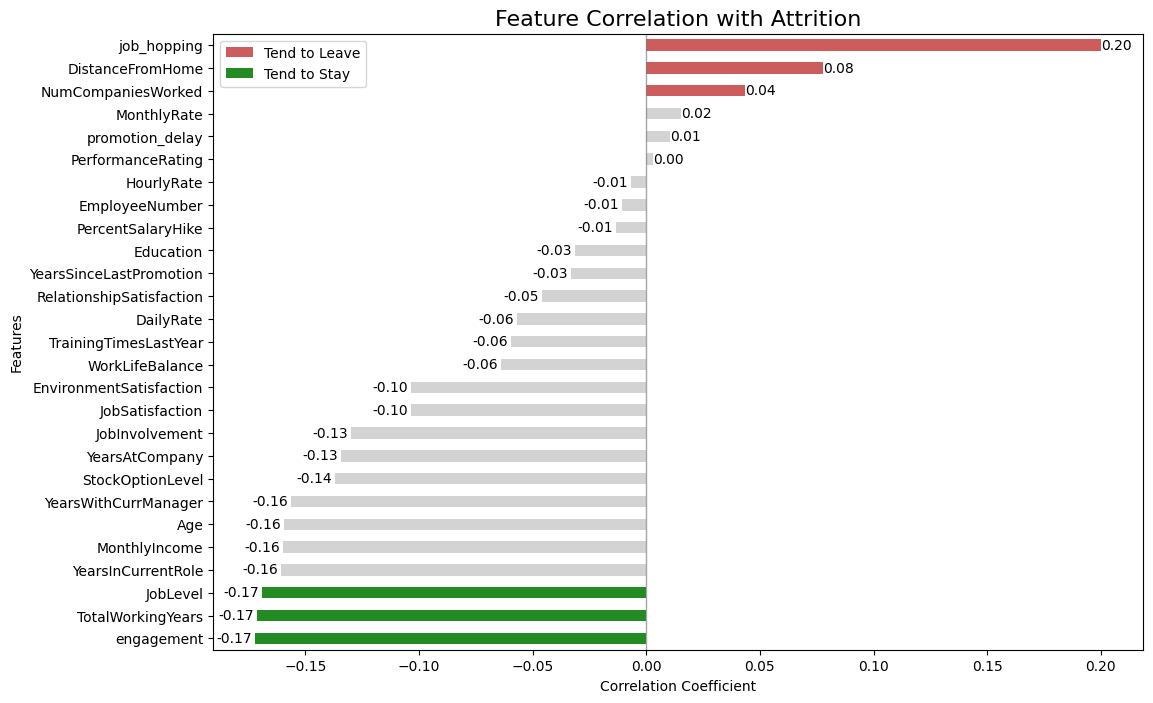

In [98]:
# =========================
# Correlation with Attrition (Highlighted Barplot)
# =========================

from matplotlib.patches import Patch

# Remove Attrition itself
attrition_corr_plot = attrition_corr.drop("Attrition")

# Sort values
sorted_corr = attrition_corr_plot.sort_values()

# Default colors
colors = ["lightgrey"] * len(sorted_corr)

# Highlight top 3 positive correlations
for i in range(-3, 0):
    colors[i] = "indianred"

# Highlight top 3 negative correlations
for i in range(3):
    colors[i] = "forestgreen"

# Create figure
plt.figure(figsize=(12, 8))

# Plot bars
ax = sorted_corr.plot(
    kind="barh",
    color=colors
)

# Add correlation values next to bars
for index, value in enumerate(sorted_corr):

    # Position labels slightly outside the bars
    if value >= 0:
        plt.text(
            value + 0.000,
            index,
            f"{value:.2f}",
            va="center"
        )
    else:
        plt.text(
            value - 0.017,
            index,
            f"{value:.2f}",
            va="center"
        )

# Vertical reference line
plt.axvline(
    0,
    color="grey",
    linewidth=1,
    alpha=0.7
)

# Custom legend
legend_elements = [
    Patch(facecolor="indianred", label="Tend to Leave"),
    Patch(facecolor="forestgreen", label="Tend to Stay")
]

plt.legend(handles=legend_elements)

# Titles and labels
plt.title("Feature Correlation with Attrition", fontsize=16)
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.show()

In [55]:
# =========================
# Final Insights from Correlation Analysis
# =========================

# The correlation analysis highlights several meaningful patterns
# associated with employee attrition.
#
# Among the engineered features, 'job_hopping' shows the strongest
# positive correlation with attrition (+0.20), suggesting that employees
# with a history of frequent company changes are more likely to leave
# the company.
#
# Conversely, 'engagement' presents the strongest negative correlation
# (-0.17), indicating that employees with higher satisfaction,
# stronger job involvement, and better work-life balance tend to remain
# employed for longer periods.
#
# Traditional organizational stability indicators such as:
# - TotalWorkingYears
# - JobLevel
# - YearsInCurrentRole
# - YearsAtCompany
#
# also show moderate negative correlations with attrition, suggesting
# that more experienced and established employees are generally less
# likely to leave.
#
# Financial and long-term incentive variables such as:
# - MonthlyIncome
# - StockOptionLevel
#
# are negatively associated with attrition as well, indicating that
# stronger compensation and financial incentives may contribute to
# employee retention.
#
# Additionally, variables related to managerial stability and workplace
# experience, including:
# - YearsWithCurrManager
# - JobInvolvement
# - EnvironmentSatisfaction
#
# also appear to be associated with lower attrition levels.
#
# Overall, the analysis suggests that employee attrition is influenced
# by a combination of:
# - low engagement
# - unstable career behavior
# - lower organizational seniority
# - weaker financial incentives
#
# The engineered features developed during this project successfully
# captured some of the most relevant behavioral patterns associated
# with employee attrition.